In [1]:
import sys
import os
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Add paths explicitly
notebook_dir = os.getcwd()
project_dir = os.path.dirname(notebook_dir)
src_dir = os.path.join(project_dir, 'src')
models_dir = os.path.join(src_dir, 'models')

sys.path.insert(0, src_dir)
sys.path.insert(0, models_dir)

print(f"Project dir: {project_dir}")
print(f"Src dir: {src_dir}")
print(f"Models dir: {models_dir}")

# Test imports one by one
print("\nTesting imports...")

import preprocess
print("✅ preprocess OK")

import evaluate
print("✅ evaluate OK")

import visualize
print("✅ visualize OK")

import isolation_forest
print("✅ isolation_forest OK")

import lof
print("✅ lof OK")

import autoencoder
print("✅ autoencoder OK")

print("\nAll imports successful!")

Project dir: d:\anomaly_detection
Src dir: d:\anomaly_detection\src
Models dir: d:\anomaly_detection\src\models

Testing imports...
✅ preprocess OK
✅ evaluate OK
✅ visualize OK
✅ isolation_forest OK
✅ lof OK
✅ autoencoder OK

All imports successful!


In [2]:
from preprocess import preprocess_pipeline

DATA_PATH = '../data/CICIDS2017/'

X_train, X_test, y_test, scaler, feature_names = preprocess_pipeline(
    data_path=DATA_PATH,
    test_size=0.2
)

Step 1: Loading data...
Found 8 CSV files
Loaded 2,830,743 rows, 79 columns

Step 2: Cleaning data...
Missing values found: 5,734
Removed 307,078 duplicate rows
Clean dataset size: 2,520,798 rows

Step 3: Extracting features and labels...
Using 26 features
Normal (BENIGN):  2,095,057 (83.1%)
Anomalous (attack): 425,741 (16.9%)

Step 4: Splitting into train and test sets...

Training set (normal only): 1,676,045 samples
Test set total:             844,753 samples
  - Normal:                 419,012
  - Anomalous:              425,741

Step 5: Standardising features...

Preprocessing complete!
  Training set shape: (1676045, 26)
  Test set shape:     (844753, 26)


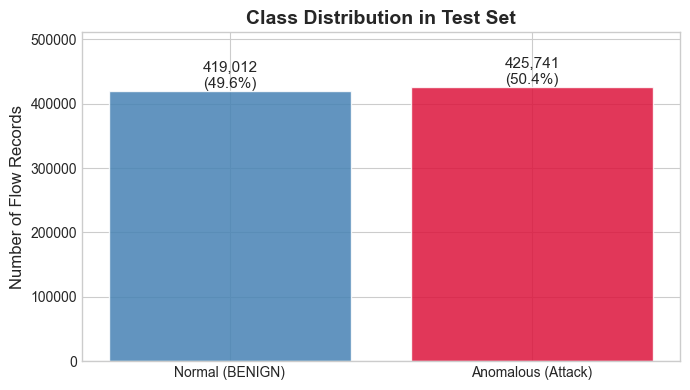

Figure 1: Class distribution saved.

Feature Statistics (Training Set - Normal Traffic Only):
                             Mean  Std Dev        Min        Max
Flow Duration                 0.0      1.0    -0.3900     3.4584
Total Fwd Packets             0.0      1.0    -0.0119   249.1707
Total Backward Packets       -0.0      1.0    -0.0113   248.8182
Total Length of Fwd Packets   0.0      1.0    -0.0574  1082.7516
Total Length of Bwd Packets   0.0      1.0    -0.0078   246.4427
Fwd Packet Length Mean        0.0      1.0    -0.3299    21.6631
Fwd Packet Length Std         0.0      1.0    -0.2497    21.7531
Bwd Packet Length Mean       -0.0      1.0    -0.5848    12.3654
Bwd Packet Length Std         0.0      1.0    -0.4699    14.0079
Flow Bytes/s                 -0.0      1.0    -6.7437    71.6878
Flow Packets/s               -0.0      1.0    -9.3901    18.0447
Flow IAT Mean                 0.0      1.0    -0.2326    28.5001
Flow IAT Std                  0.0      1.0    -0.2810    13.6

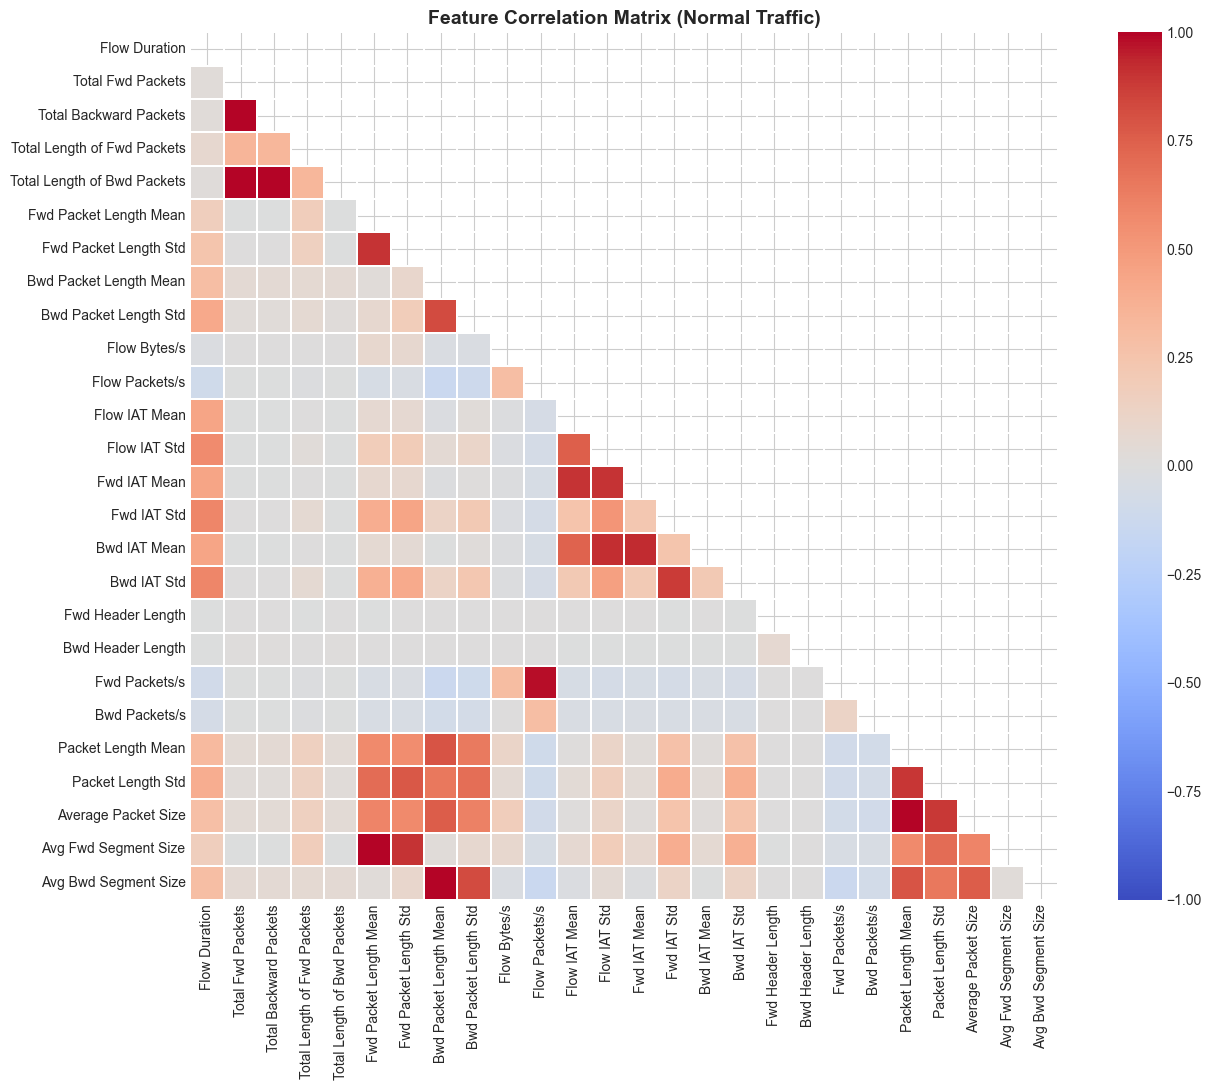

Figure 2: Correlation heatmap saved.


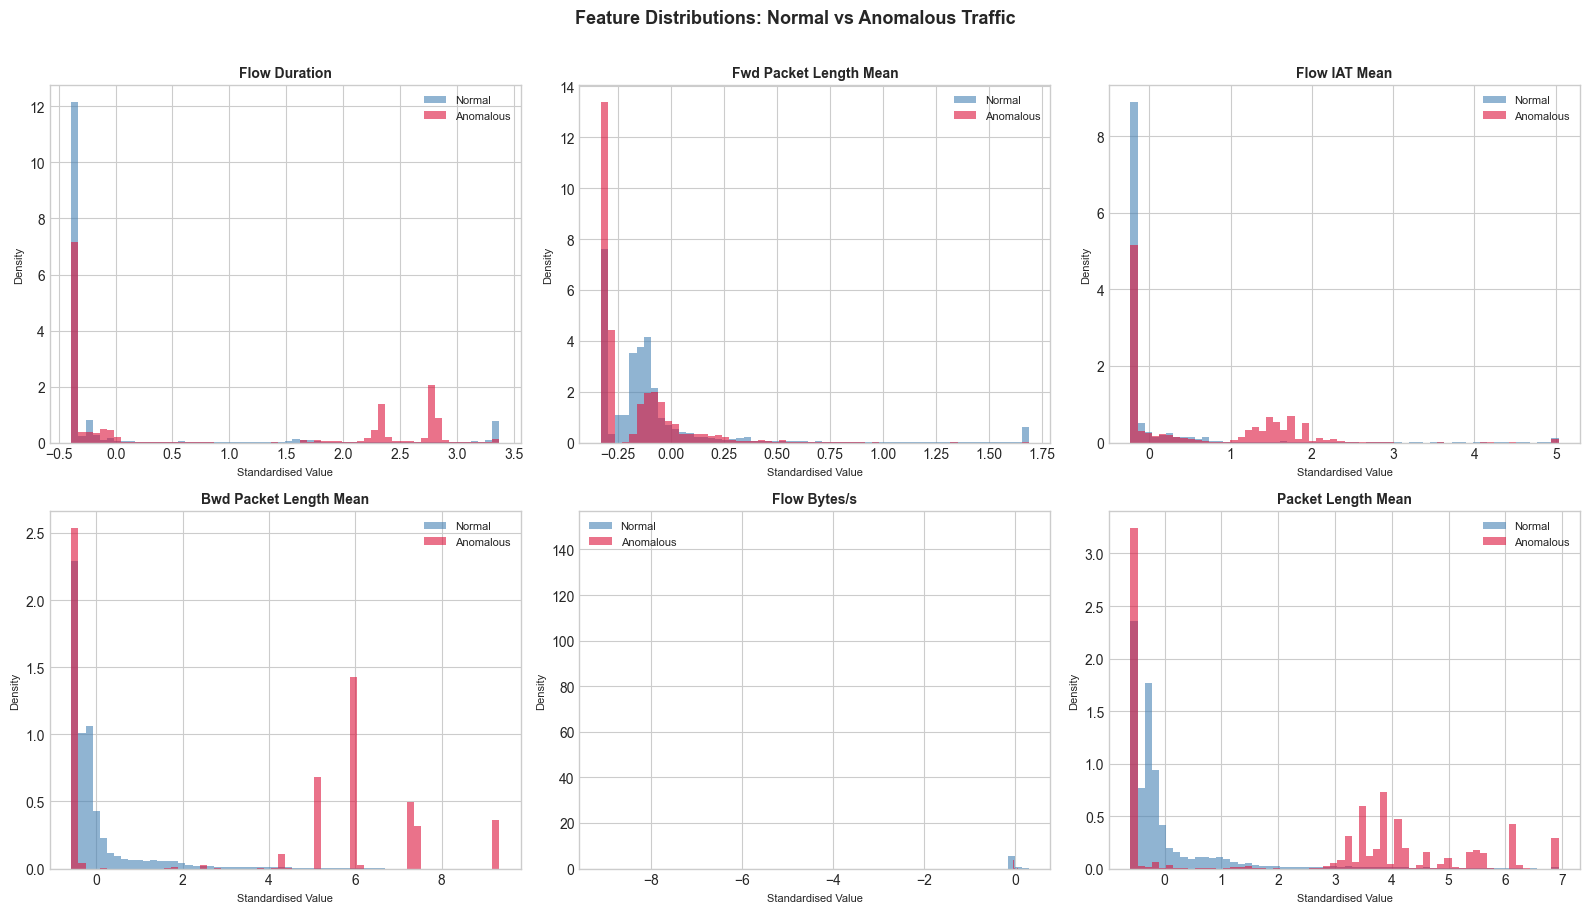

Figure 3: Feature distributions saved.

EDA Complete! All figures saved to ../outputs/figures/

Dataset Summary:
  Total records after cleaning: 2,520,798
  Features used:                26
  Training set (normal only):   1,676,045
  Test set (normal + anomaly):  844,753
    - Normal:                   419,012
    - Anomalous:                425,741


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

os.makedirs('../outputs/figures', exist_ok=True)

# ── 1. Class Distribution ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
labels = ['Normal (BENIGN)', 'Anomalous (Attack)']
counts = [(y_test == 0).sum(), (y_test == 1).sum()]
colors = ['steelblue', 'crimson']
bars = ax.bar(labels, counts, color=colors, alpha=0.85, edgecolor='white')
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 5000,
            f'{count:,}\n({count/sum(counts)*100:.1f}%)',
            ha='center', fontsize=11)
ax.set_title('Class Distribution in Test Set', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Flow Records', fontsize=12)
ax.set_ylim(0, max(counts) * 1.2)
plt.tight_layout()
plt.savefig('../outputs/figures/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1: Class distribution saved.")

# ── 2. Feature Statistics ─────────────────────────────────────────
X_train_df = pd.DataFrame(X_train, columns=feature_names)
stats = X_train_df.describe().T[['mean', 'std', 'min', 'max']]
stats.columns = ['Mean', 'Std Dev', 'Min', 'Max']
stats = stats.round(4)
print("\nFeature Statistics (Training Set - Normal Traffic Only):")
print(stats.to_string())
stats.to_csv('../outputs/feature_statistics.csv')
print("\nFeature statistics saved to ../outputs/feature_statistics.csv")

# ── 3. Feature Correlation Heatmap ───────────────────────────────
fig, ax = plt.subplots(figsize=(14, 11))
corr_matrix = X_train_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=False,
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.3,
    ax=ax
)
ax.set_title('Feature Correlation Matrix (Normal Traffic)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2: Correlation heatmap saved.")



# ── 4. Feature Distributions: Normal vs Anomalous ────────────────
key_features = [
    'Flow Duration',
    'Fwd Packet Length Mean',
    'Flow IAT Mean',
    'Bwd Packet Length Mean',
    'Flow Bytes/s',
    'Packet Length Mean'
]

key_indices = [feature_names.index(f) for f in key_features if f in feature_names]
key_names = [feature_names[i] for i in key_indices]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

# Fix: use numpy boolean indexing instead of iloc
X_test_arr = np.array(X_test)
y_test_arr = np.array(y_test)

for idx, (feat_idx, feat_name) in enumerate(zip(key_indices, key_names)):
    ax = axes[idx]

    # Use numpy indexing directly
    normal_vals = X_test_arr[y_test_arr == 0, feat_idx]
    anomaly_vals = X_test_arr[y_test_arr == 1, feat_idx]

    # Clip to 99th percentile for better visualisation
    upper = np.percentile(X_test_arr[:, feat_idx], 99)
    normal_clipped = np.clip(normal_vals, None, upper)
    anomaly_clipped = np.clip(anomaly_vals, None, upper)

    ax.hist(normal_clipped, bins=60, alpha=0.6,
            color='steelblue', label='Normal', density=True)
    ax.hist(anomaly_clipped, bins=60, alpha=0.6,
            color='crimson', label='Anomalous', density=True)
    ax.set_title(feat_name, fontsize=10, fontweight='bold')
    ax.set_xlabel('Standardised Value', fontsize=8)
    ax.set_ylabel('Density', fontsize=8)
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions: Normal vs Anomalous Traffic',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/figures/feature_distributions.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 3: Feature distributions saved.")

# ── 5. Attack Type Breakdown ──────────────────────────────────────
print("\nEDA Complete! All figures saved to ../outputs/figures/")
print(f"\nDataset Summary:")
print(f"  Total records after cleaning: 2,520,798")
print(f"  Features used:                {len(feature_names)}")
print(f"  Training set (normal only):   {len(X_train):,}")
print(f"  Test set (normal + anomaly):  {len(X_test):,}")
print(f"    - Normal:                   {(y_test==0).sum():,}")
print(f"    - Anomalous:                {(y_test==1).sum():,}")

In [4]:
from isolation_forest import run_isolation_forest

if_scores, if_results, if_detector = run_isolation_forest(
    X_train=X_train,
    X_test=X_test,
    y_test=y_test,
    n_estimators=100,
    contamination=0.05,
    k_values=[50, 100, 200]
)

Training Isolation Forest with 100 trees...
Training complete.
Scoring test set with Isolation Forest...

Evaluation Results: Isolation Forest
AUC-ROC:            0.8057
Average Precision:  0.8145
Precision@50:      0.2000
Precision@100:      0.1000
Precision@200:      0.0550
Threshold:          0.6813
Precision:          0.9148
Recall:             0.0909
F1-Score:           0.1654


Calculating feature importance...

Top 10 Most Important Features (Isolation Forest):
                    Feature  Importance
      Bwd Packet Length Std    0.021549
       Avg Bwd Segment Size    0.017485
        Average Packet Size    0.016518
          Packet Length Std    0.016200
     Bwd Packet Length Mean    0.014531
                Fwd IAT Std    0.012799
         Packet Length Mean    0.011908
              Flow Duration    0.010377
               Flow IAT Std    0.010293
Total Length of Bwd Packets    0.008001


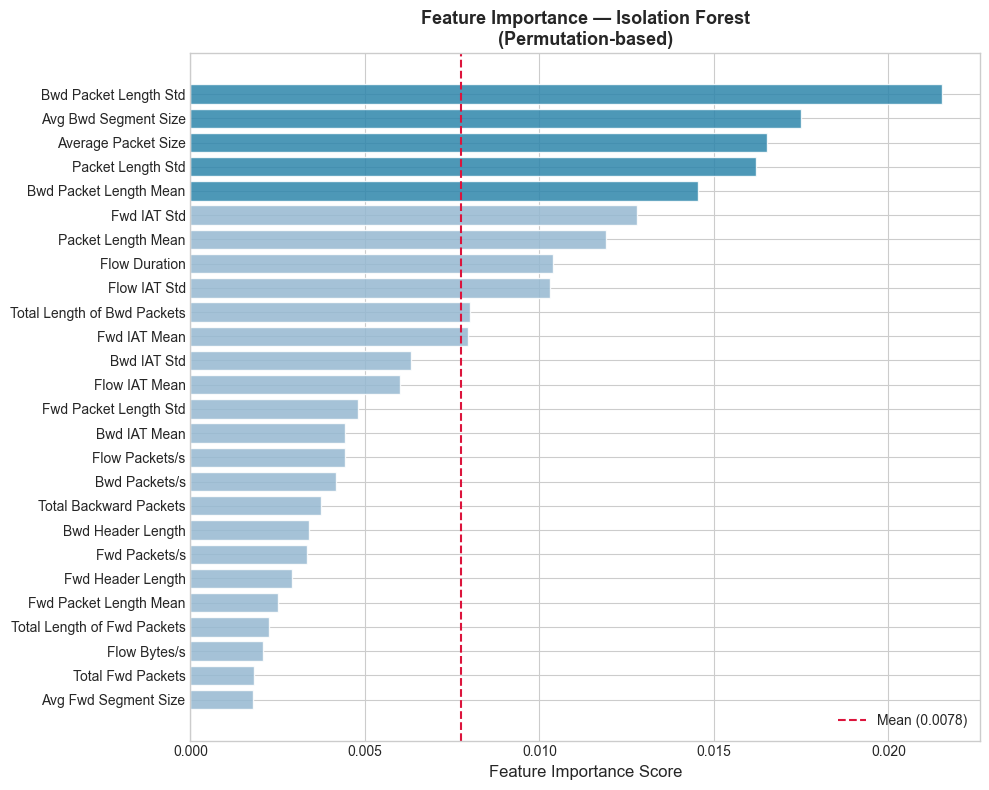

Feature importance saved!


In [5]:
# ── Feature Importance from Isolation Forest ──────────────────────
# Isolation Forest does not have feature_importances_ directly
# We use mean anomaly score difference per feature instead

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Calculate feature importance using permutation-based approach
# Compare anomaly scores when each feature is shuffled
print("Calculating feature importance...")

base_scores = if_detector.predict_scores(X_test)

feature_importance = []
for i, feat_name in enumerate(feature_names):
    # Shuffle one feature at a time
    X_permuted = X_test.copy()
    np.random.seed(42)
    np.random.shuffle(X_permuted[:, i])
    
    # Get new scores with shuffled feature
    permuted_scores = if_detector.predict_scores(X_permuted)
    
    # Importance = how much scores change when feature is shuffled
    importance = np.mean(np.abs(base_scores - permuted_scores))
    feature_importance.append(importance)

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features (Isolation Forest):")
print(importance_df.head(10).to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#2E86AB' if i < 5 else '#95B8D1'
          for i in range(len(importance_df))]
ax.barh(
    importance_df['Feature'][::-1],
    importance_df['Importance'][::-1],
    color=colors[::-1],
    alpha=0.85,
    edgecolor='white'
)
ax.set_xlabel('Feature Importance Score', fontsize=12)
ax.set_title('Feature Importance — Isolation Forest\n(Permutation-based)',
             fontsize=13, fontweight='bold')
ax.axvline(x=np.mean(feature_importance), color='crimson',
           linestyle='--', linewidth=1.5,
           label=f'Mean ({np.mean(feature_importance):.4f})')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../outputs/figures/feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

importance_df.to_csv('../outputs/feature_importance.csv', index=False)
print("Feature importance saved!")

In [6]:
from lof import run_lof
from sklearn.utils import resample

# Sample 10,000 records from test set for LOF
# LOF does not scale well to large datasets due to O(n²) complexity
print("Sampling 10,000 records for LOF evaluation...")
sample_size = 10000
sample_indices = resample(
    range(len(X_test)),
    n_samples=sample_size,
    random_state=42
)
X_test_lof = X_test[sample_indices]
y_test_lof = y_test[sample_indices]

print(f"LOF test sample: {len(X_test_lof):,} records")
print(f"  - Normal:     {(y_test_lof==0).sum():,}")
print(f"  - Anomalous:  {(y_test_lof==1).sum():,}")

lof_scores, lof_results, lof_detector = run_lof(
    X_test=X_test_lof,
    y_test=y_test_lof,
    n_neighbors=20,
    contamination=0.05,
    k_values=[50, 100, 200]
)

Sampling 10,000 records for LOF evaluation...
LOF test sample: 10,000 records
  - Normal:     4,940
  - Anomalous:  5,060

Scoring test set with LOF...
Fitting LOF with k=20 neighbours...
LOF scoring complete.

Evaluation Results: Local Outlier Factor
AUC-ROC:            0.4321
Average Precision:  0.4708
Precision@50:      0.5000
Precision@100:      0.6100
Precision@200:      0.5350
Threshold:          2.8503
Precision:          0.4980
Recall:             0.0492
F1-Score:           0.0896


In [7]:
from autoencoder import run_autoencoder

ae_scores, ae_results, ae_detector = run_autoencoder(
    X_train=X_train,
    X_test=X_test,
    y_test=y_test,
    encoding_dim=8,
    learning_rate=0.001,
    epochs=50,
    batch_size=256,
    k_values=[50, 100, 200]
)

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 26)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_1 (Dense)               │ (None, 32)             │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_2 (Dense)               │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_1 (Dense)               │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_2 (Dense)               │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 26)             │           858 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,074 (12.01 KB)

 Trainable params: 3,074 (12.01 KB)

 Non-trainable params: 0 (0.00 B)


Training Autoencoder for up to 50 epochs...
Input dimension: 26
Bottleneck dimension: 8
Epoch 1/50
5893/5893 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - loss: 0.2162 - val_loss: 0.0315
Epoch 2/50
5893/5893 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - loss: 0.1353 - val_loss: 0.0235
Epoch 3/50
5893/5893 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 0.1048 - val_loss: 0.0254
Epoch 4/50
5893/5893 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 0.0947 - val_loss: 0.0260
Epoch 5/50
5893/5893 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 0.0739 - val_loss: 0.0224
Epoch 6/50
5893/5893 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 0.0569 - val_loss: 0.0209
Epoch 7/50
5893/5893 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 0.0482 - val_loss: 0.0262
Epoch 8/50
5893/5893 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 0.0438 - val_loss: 0.0191
Epoch 9/50
5893/5893 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 0.0491 - val_loss: 0.0255
Epoch 10/50
5893/5893 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 0.0286 - val_loss: 0.0199
Epoch 11/50
5893/5893 ━━━━━━━━

In [8]:
from evaluate import compare_models

all_results = [if_results, lof_results, ae_results]
compare_models(all_results)


Model Comparison Summary
Model                   AUC-ROC   Avg Prec     P@50    P@100    P@200       F1
----------------------------------------------------------------------
Isolation Forest         0.8057     0.8145   0.2000   0.1000   0.0550   0.1654
Local Outlier Factor     0.4321     0.4708   0.5000   0.6100   0.5350   0.0896
Autoencoder              0.7755     0.8282   0.3400   0.3800   0.6550   0.1774


Figure saved to ../outputs/figures/roc_curves.png


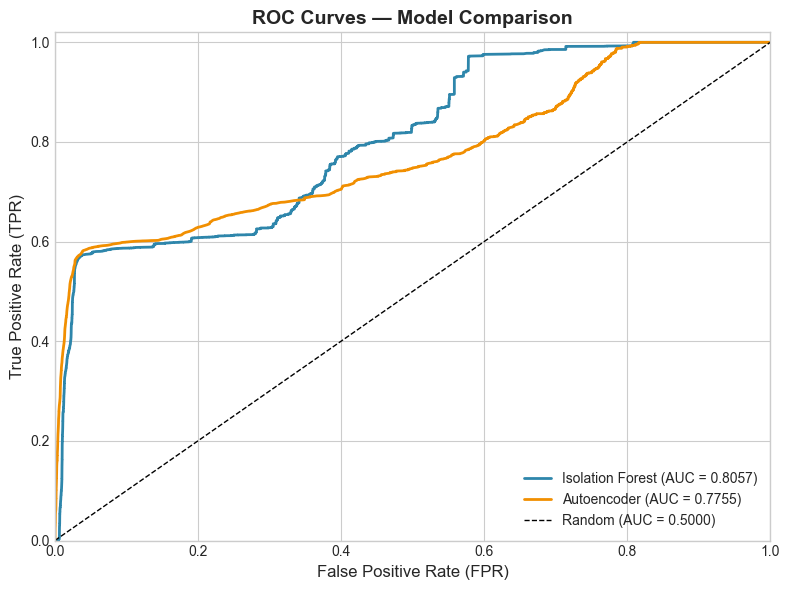

Figure saved to ../outputs/figures/pr_curves.png


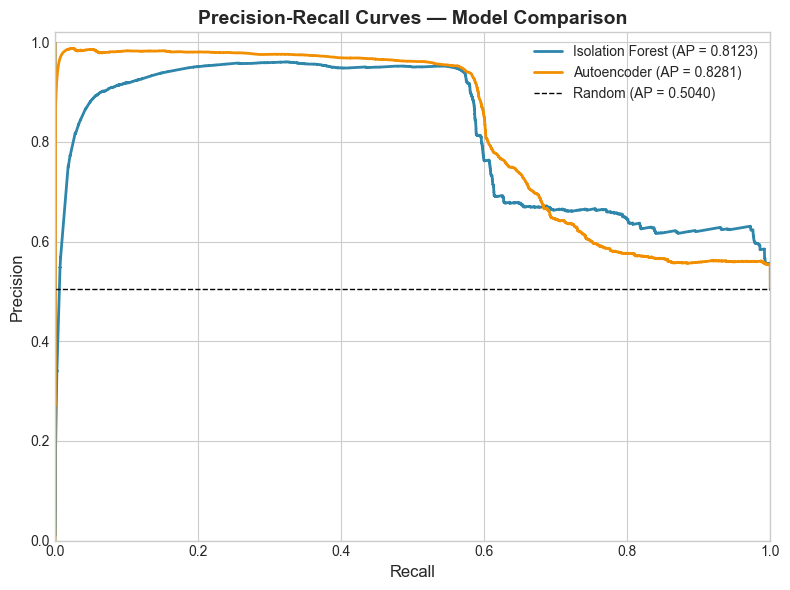

Figure saved to ../outputs/figures/score_distributions.png


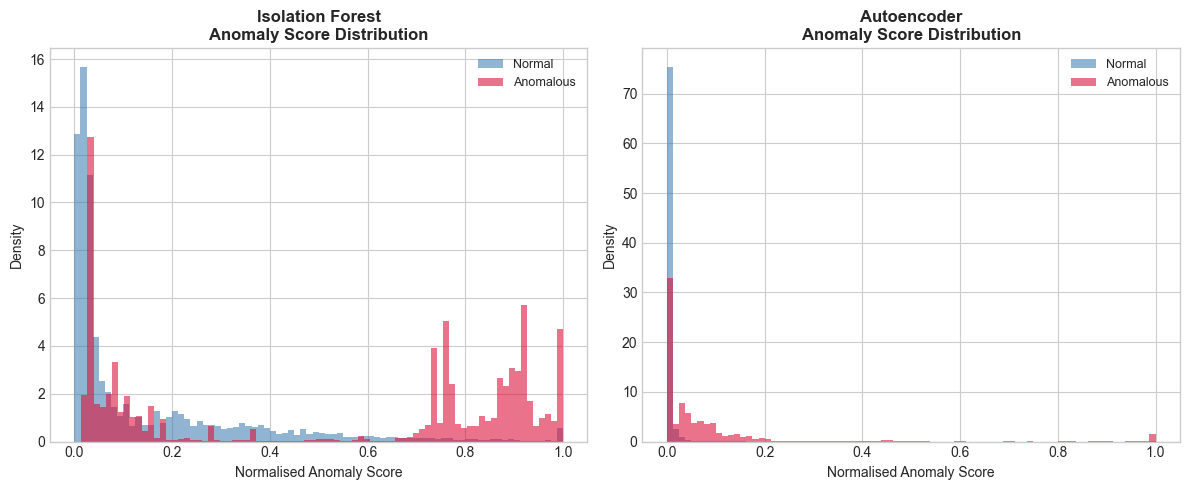

Figure saved to ../outputs/figures/roc_curve_lof.png


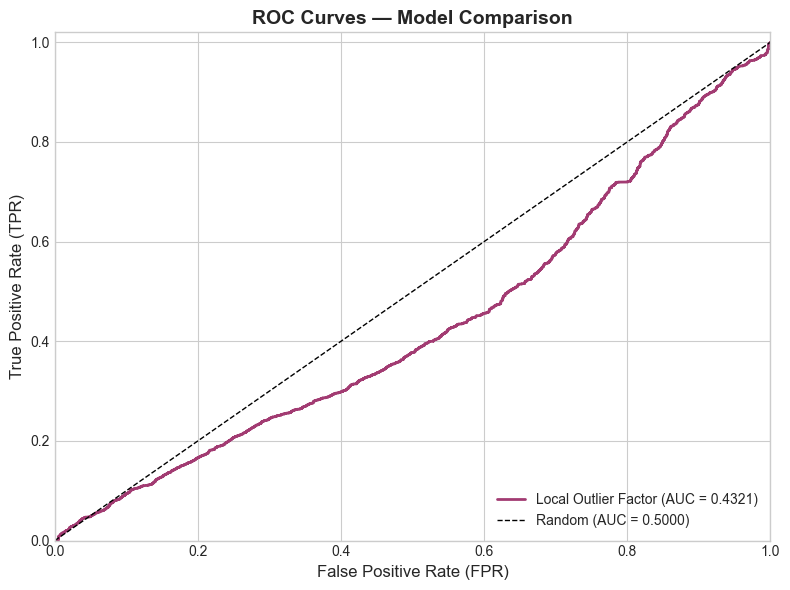

Figure saved to ../outputs/figures/pr_curve_lof.png


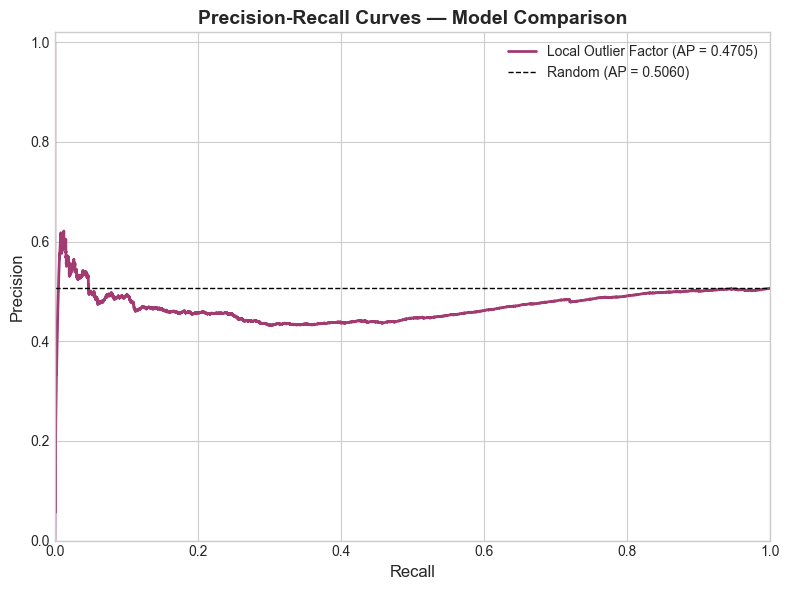

Figure saved to ../outputs/figures/score_distribution_lof.png


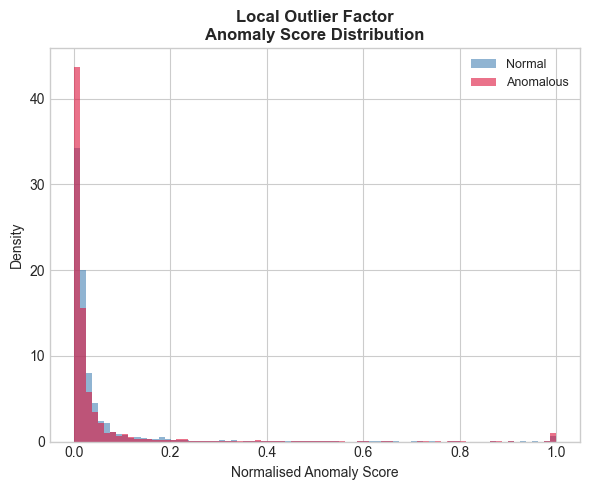

Figure saved to ../outputs/figures/precision_at_k.png


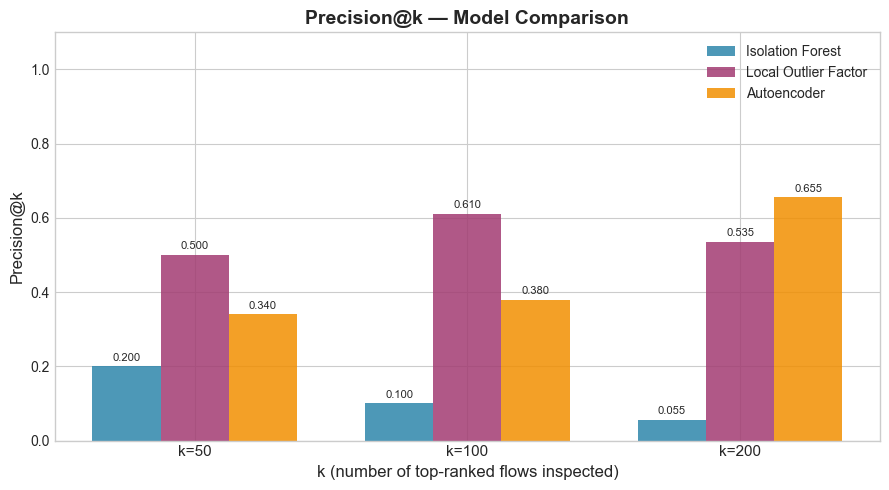

Figure saved to ../outputs/figures/training_curve.png


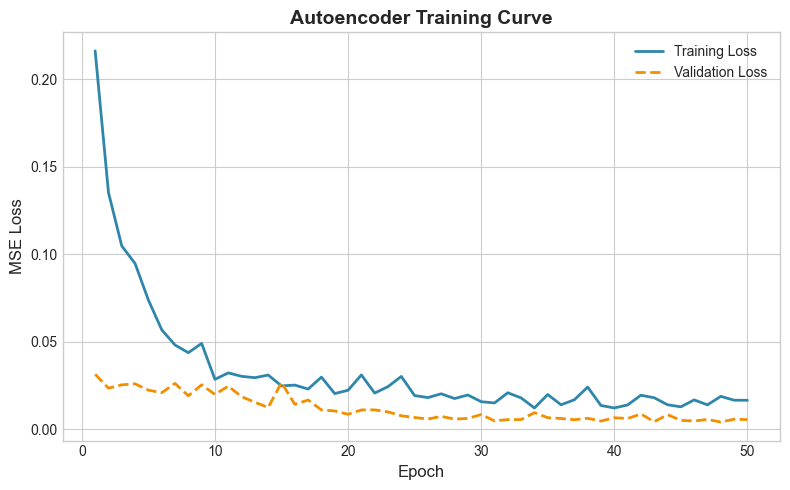

Dashboard saved to ../outputs/figures/summary_dashboard.png


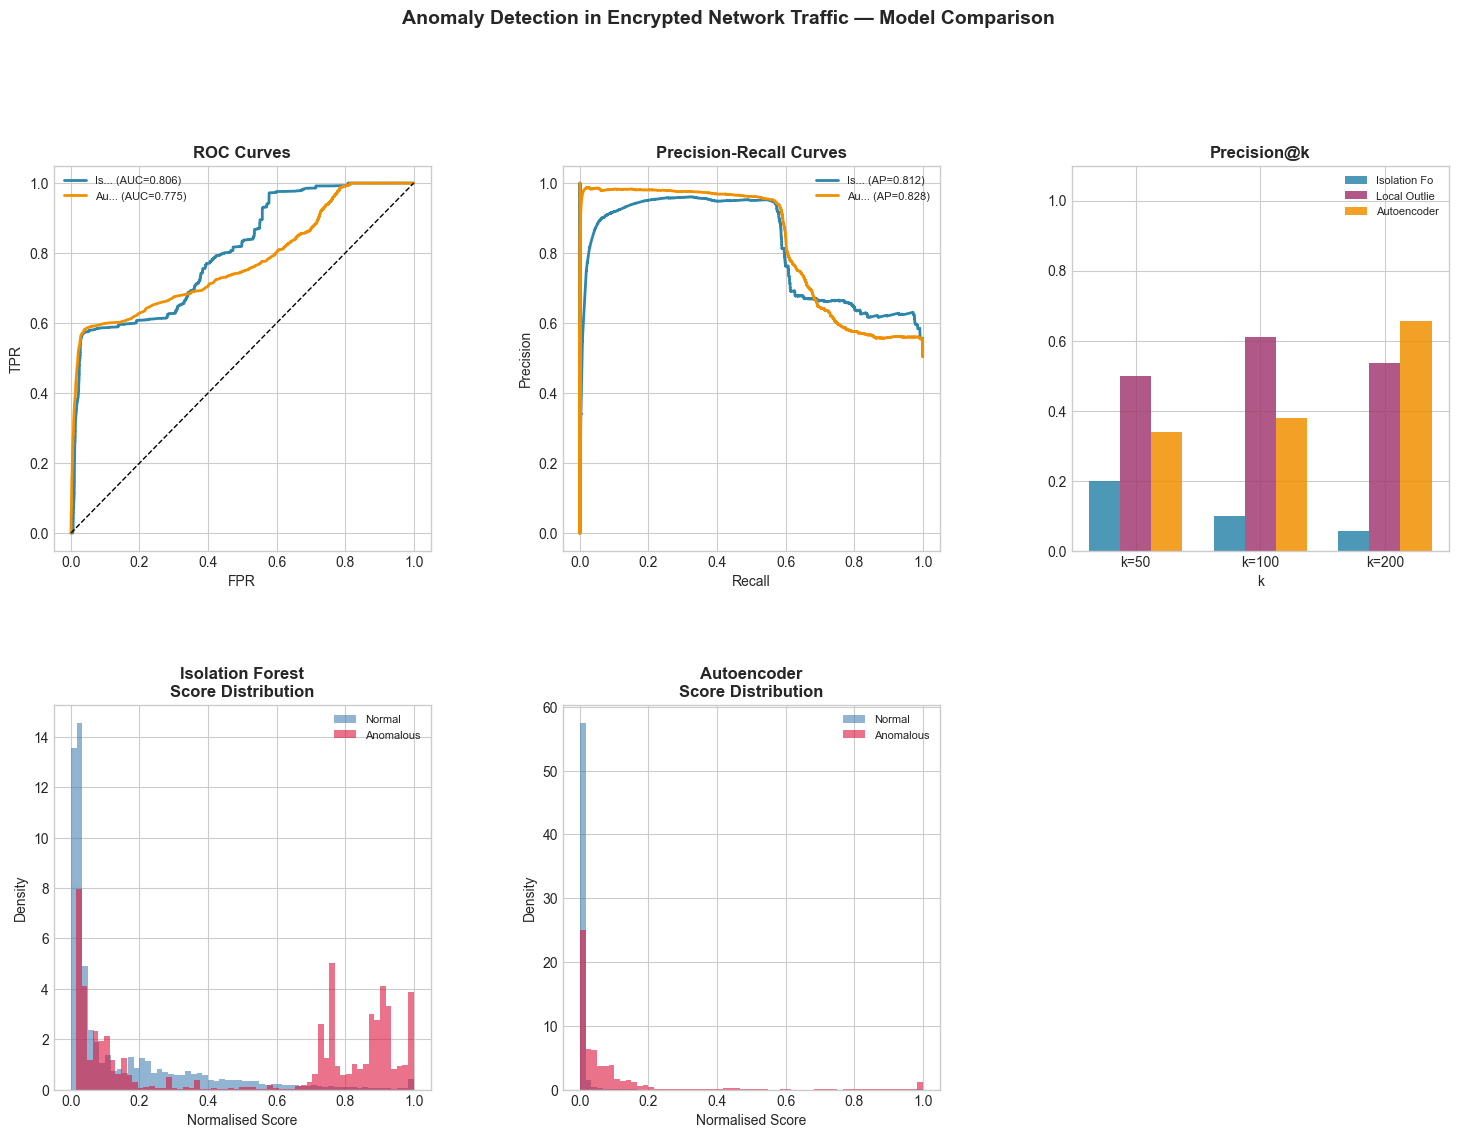

In [9]:
from visualize import (
    plot_score_distribution,
    plot_roc_curves,
    plot_pr_curves,
    plot_precision_at_k,
    plot_training_curve,
    plot_summary_dashboard
)

os.makedirs('../outputs/figures', exist_ok=True)

# ── Isolation Forest + Autoencoder：用完整测试集（844,753条），长度一致 ──
scores_dict_main = {
    'Isolation Forest': if_scores,
    'Autoencoder': ae_scores
}

plot_roc_curves(scores_dict=scores_dict_main, y_test=y_test,
    save_path='../outputs/figures/roc_curves.png')
plot_pr_curves(scores_dict=scores_dict_main, y_test=y_test,
    save_path='../outputs/figures/pr_curves.png')
plot_score_distribution(scores_dict=scores_dict_main, y_test=y_test,
    save_path='../outputs/figures/score_distributions.png')

# ── LOF：因为是10,000条采样子集，单独画，用对应的 y_test_lof ──
scores_dict_lof = {'Local Outlier Factor': lof_scores}

plot_roc_curves(scores_dict=scores_dict_lof, y_test=y_test_lof,
    save_path='../outputs/figures/roc_curve_lof.png')
plot_pr_curves(scores_dict=scores_dict_lof, y_test=y_test_lof,
    save_path='../outputs/figures/pr_curve_lof.png')
plot_score_distribution(scores_dict=scores_dict_lof, y_test=y_test_lof,
    save_path='../outputs/figures/score_distribution_lof.png')

# ── 不受影响，保持不变 ──
plot_precision_at_k(all_results=all_results, k_values=[50, 100, 200],
    save_path='../outputs/figures/precision_at_k.png')

history = ae_detector.get_training_history()
plot_training_curve(history=history,
    save_path='../outputs/figures/training_curve.png')

# ── summary dashboard：只放IF和AE两个（长度一致），LOF不放进这张综合图里 ──
plot_summary_dashboard(scores_dict=scores_dict_main, y_test=y_test,
    all_results=all_results,
    save_path='../outputs/figures/summary_dashboard.png')

In [10]:
import pandas as pd

rows = []
for result in all_results:
    rows.append({
        'Model': result['model'],
        'AUC-ROC': round(result['auc_roc'], 4),
        'Average Precision': round(result['average_precision'], 4),
        'Precision@50': round(result.get('precision@50', 0), 4),
        'Precision@100': round(result.get('precision@100', 0), 4),
        'Precision@200': round(result.get('precision@200', 0), 4),
        'Precision': round(result['precision'], 4),
        'Recall': round(result['recall'], 4),
        'F1-Score': round(result['f1'], 4),
    })

results_df = pd.DataFrame(rows)
os.makedirs('../outputs', exist_ok=True)
results_df.to_csv('../outputs/results.csv', index=False)

print("Results saved to ../outputs/results.csv")
print("\nFinal Results Table:")
print(results_df.to_string(index=False))

Results saved to ../outputs/results.csv

Final Results Table:
               Model  AUC-ROC  Average Precision  Precision@50  Precision@100  Precision@200  Precision  Recall  F1-Score
    Isolation Forest   0.8057             0.8145          0.20           0.10          0.055     0.9148  0.0909    0.1654
Local Outlier Factor   0.4321             0.4708          0.50           0.61          0.535     0.4980  0.0492    0.0896
         Autoencoder   0.7755             0.8282          0.34           0.38          0.655     0.9825  0.0975    0.1774


Loading attack type breakdown...

Attack Type Distribution:
               Attack Type   Count
                    BENIGN 2273097
                  DoS Hulk  231073
                  PortScan  158930
                      DDoS  128027
             DoS GoldenEye   10293
               FTP-Patator    7938
               SSH-Patator    5897
             DoS slowloris    5796
          DoS Slowhttptest    5499
                       Bot    1966
  Web Attack � Brute Force    1507
          Web Attack � XSS     652
              Infiltration      36
Web Attack � Sql Injection      21
                Heartbleed      11


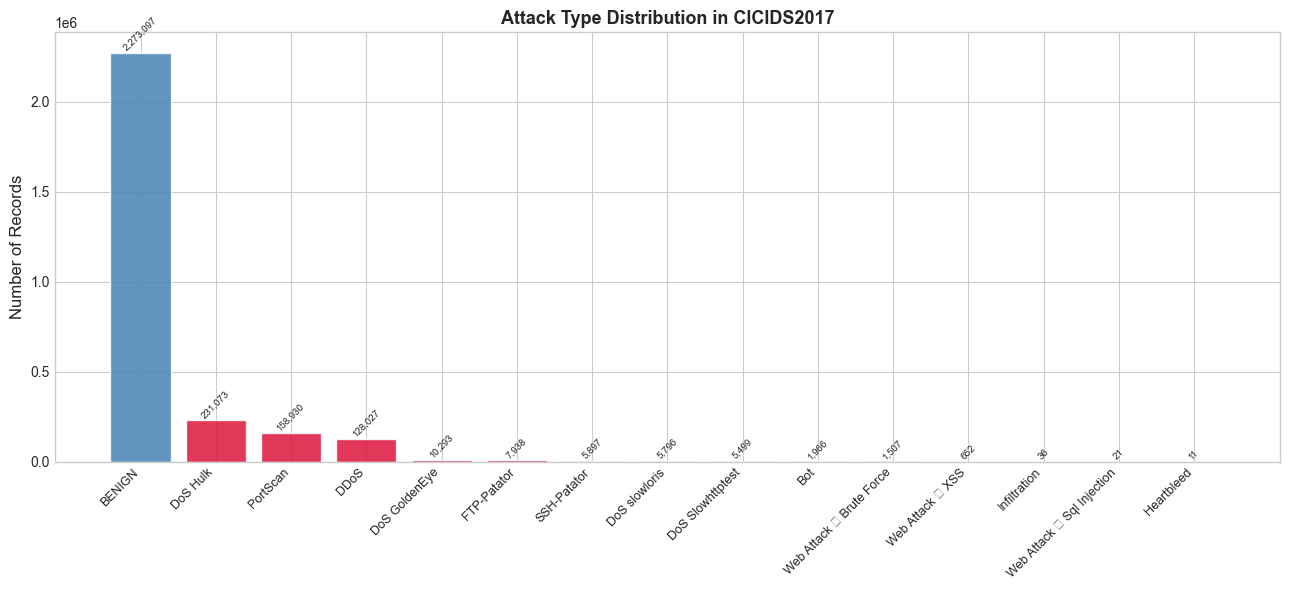


Attack distribution saved!


In [11]:
# ── Attack Type Distribution ──────────────────────────────────────
import os
import pandas as pd
import matplotlib.pyplot as plt

print("Loading attack type breakdown...")
data_dir = '../data/CICIDS2017/'
all_files = [os.path.join(data_dir, f) 
             for f in os.listdir(data_dir) 
             if f.endswith('.csv')]

label_counts = {}
for f in all_files:
    df_temp = pd.read_csv(f, usecols=[' Label'],
                          encoding='utf-8', low_memory=False)
    df_temp.columns = df_temp.columns.str.strip()
    counts = df_temp['Label'].value_counts()
    for label, count in counts.items():
        label = label.strip()
        label_counts[label] = label_counts.get(label, 0) + count

attack_df = pd.DataFrame({
    'Attack Type': list(label_counts.keys()),
    'Count': list(label_counts.values())
}).sort_values('Count', ascending=False)

print("\nAttack Type Distribution:")
print(attack_df.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(13, 6))
colors = ['steelblue' if t == 'BENIGN' else 'crimson'
          for t in attack_df['Attack Type']]
bars = ax.bar(range(len(attack_df)), attack_df['Count'],
              color=colors, alpha=0.85, edgecolor='white')
ax.set_xticks(range(len(attack_df)))
ax.set_xticklabels(attack_df['Attack Type'],
                   rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Number of Records', fontsize=12)
ax.set_title('Attack Type Distribution in CICIDS2017',
             fontsize=13, fontweight='bold')
for bar, count in zip(bars, attack_df['Count']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1000,
            f'{count:,}',
            ha='center', va='bottom', fontsize=7, rotation=45)
plt.tight_layout()
plt.savefig('../outputs/figures/attack_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

attack_df.to_csv('../outputs/attack_distribution.csv', index=False)
print("\nAttack distribution saved!")